# BUU-LSPINE Dataset Exploration

```
Author: Arya Shah
```

First I am trying to write a minimal script to plot the annotations from CSV onto the Images

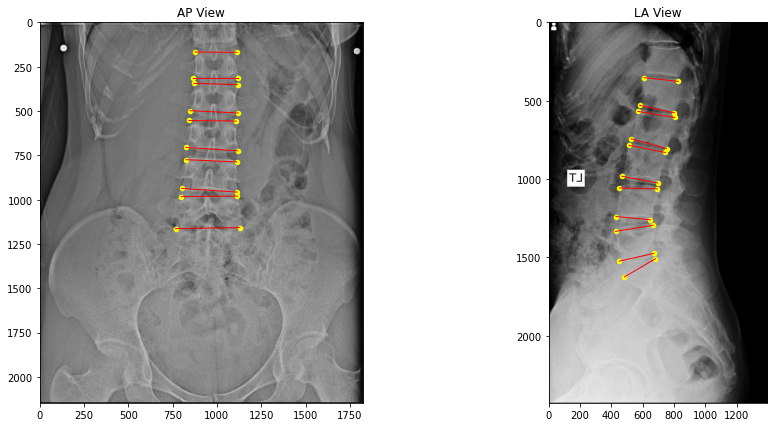

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
import numpy as np

class BUUSpineDataset:
    def __init__(self, base_path):
        self.base_path = base_path
        self.ap_path = os.path.join(base_path, 'AP')
        self.la_path = os.path.join(base_path, 'LA')
        
    def load_case(self, case_id):
        # Load AP view
        ap_image = Image.open(os.path.join(self.ap_path, f'{case_id}Y0.jpg'))
        ap_coords = pd.read_csv(os.path.join(self.ap_path, f'{case_id}Y0.csv'), 
                              header=None, 
                              names=['x1', 'y1', 'x2', 'y2', 'class'])
        
        # Load LA view
        la_image = Image.open(os.path.join(self.la_path, f'{case_id}Y1.jpg'))
        la_coords = pd.read_csv(os.path.join(self.la_path, f'{case_id}Y1.csv'),
                              header=None,
                              names=['x1', 'y1', 'x2', 'y2', 'class'])
        
        return ap_image, la_image, ap_coords, la_coords
    
    def visualize_case(self, case_id):
        ap_img, la_img, ap_coords, la_coords = self.load_case(case_id)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
        
        # Plot AP view with vertebral lines
        ax1.imshow(ap_img, cmap='gray')
        for _, row in ap_coords.iterrows():
            ax1.plot([row.x1, row.x2], [row.y1, row.y2], 'r-', linewidth=1)
            ax1.scatter([row.x1, row.x2], [row.y1, row.y2], c='yellow', s=20)
        ax1.set_title('AP View')
        
        # Plot LA view with vertebral lines
        ax2.imshow(la_img, cmap='gray')
        for _, row in la_coords.iterrows():
            ax2.plot([row.x1, row.x2], [row.y1, row.y2], 'r-', linewidth=1)
            ax2.scatter([row.x1, row.x2], [row.y1, row.y2], c='yellow', s=20)
        ax2.set_title('LA View')
        
        plt.show()
        
    def get_vertebrae_info(self, coords):
        vertebrae = []
        # Use .iloc if available, otherwise use standard indexing
        use_iloc = hasattr(coords, "iloc")
        for i in range(0, len(coords), 2):
            if i + 1 < len(coords):
                if use_iloc:
                    upper = coords.iloc[i]
                    lower = coords.iloc[i+1]
                else:
                    upper = coords[i]
                    lower = coords[i+1]
                vertebrae.append({
                    "upper": upper,
                    "lower": lower
            })
        return vertebrae

# Usage example
dataset = BUUSpineDataset('E:\BUU-LSPINE\BUU-LSPINE_400\BUU-LSPINE_400')
dataset.visualize_case('0001-F-037')


In [8]:
dataset.get_vertebrae_info('0001-F-037')

[{'upper': '0', 'lower': '0'},
 {'upper': '0', 'lower': '1'},
 {'upper': '-', 'lower': 'F'},
 {'upper': '-', 'lower': '0'},
 {'upper': '3', 'lower': '7'}]

Now going a bit deeper to gain more information from these images

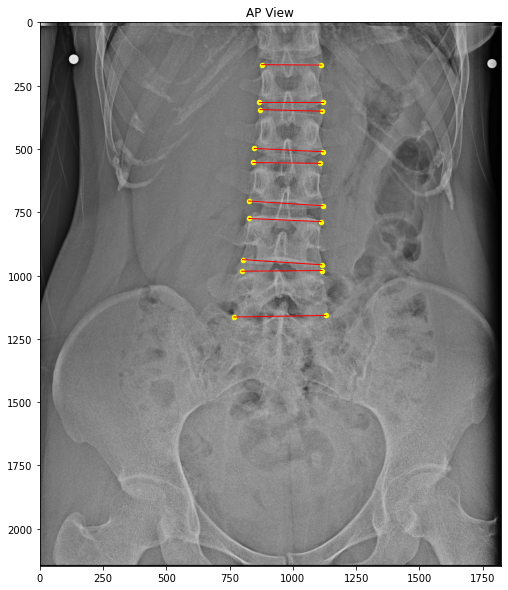

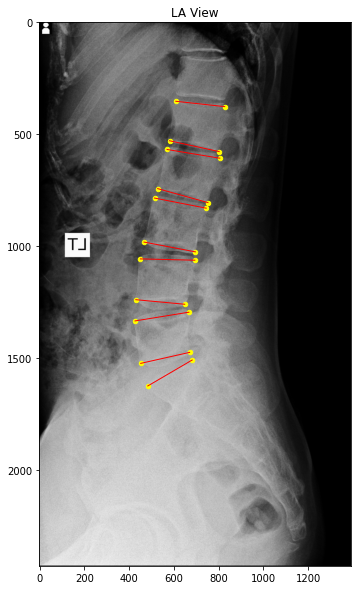

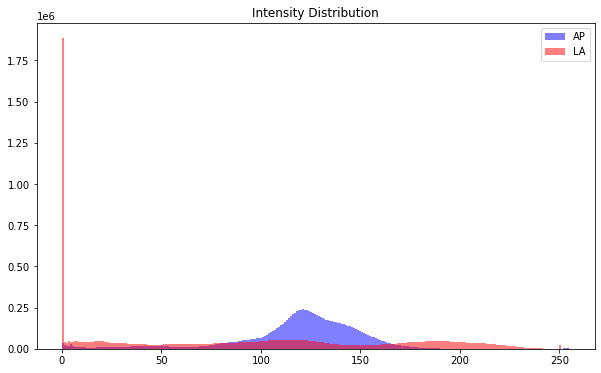

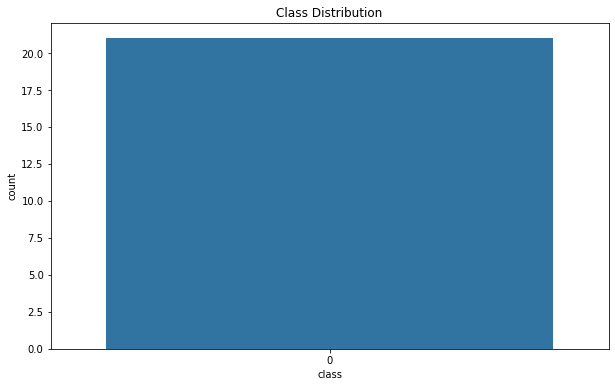

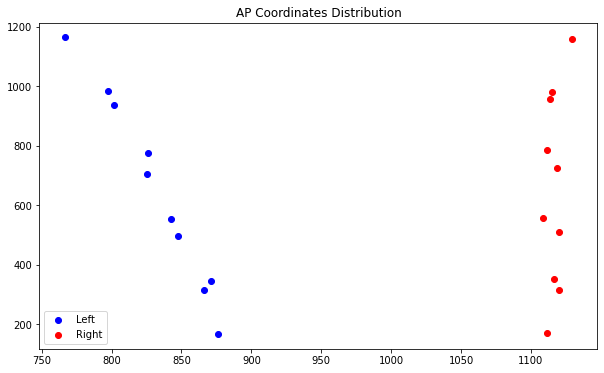

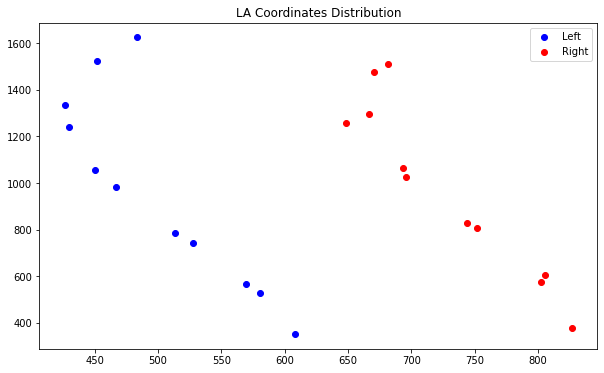

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
import numpy as np
import seaborn as sns
from pathlib import Path

class BUUSpineDataset:
    def __init__(self, base_path):
        self.base_path = base_path
        self.ap_path = os.path.join(base_path, 'AP')
        self.la_path = os.path.join(base_path, 'LA')
        
    def load_case(self, case_id):
        # Load AP view
        ap_image = Image.open(os.path.join(self.ap_path, f'{case_id}Y0.jpg'))
        ap_coords = pd.read_csv(os.path.join(self.ap_path, f'{case_id}Y0.csv'), 
                              header=None, 
                              names=['x1', 'y1', 'x2', 'y2', 'class'])
        
        # Load LA view
        la_image = Image.open(os.path.join(self.la_path, f'{case_id}Y1.jpg'))
        la_coords = pd.read_csv(os.path.join(self.la_path, f'{case_id}Y1.csv'),
                              header=None,
                              names=['x1', 'y1', 'x2', 'y2', 'class'])
        
        return ap_image, la_image, ap_coords, la_coords
    
    def visualize_case(self, case_id, save_dir=None):
        ap_img, la_img, ap_coords, la_coords = self.load_case(case_id)
        
        # Create separate plots
        plots = {
            'ap_view': self._plot_ap_view(ap_img, ap_coords),
            'la_view': self._plot_la_view(la_img, la_coords),
            'intensity_dist': self._plot_intensity_distribution(ap_img, la_img),
            'class_dist': self._plot_class_distribution(ap_coords, la_coords),
            'ap_coords': self._plot_ap_coordinates(ap_coords),
            'la_coords': self._plot_la_coordinates(la_coords)
        }
        
        if save_dir:
            save_path = Path(save_dir) / case_id
            save_path.mkdir(parents=True, exist_ok=True)
            for name, fig in plots.items():
                fig.savefig(save_path / f'{name}.png', dpi=300, bbox_inches='tight')
                plt.close(fig)
        else:
            for fig in plots.values():
                plt.show()
                
    def _plot_ap_view(self, ap_img, ap_coords):
        fig, ax = plt.subplots(figsize=(10, 10))
        ax.imshow(ap_img, cmap='gray')
        for _, row in ap_coords.iterrows():
            ax.plot([row.x1, row.x2], [row.y1, row.y2], 'r-', linewidth=1)
            ax.scatter([row.x1, row.x2], [row.y1, row.y2], c='yellow', s=20)
        ax.set_title('AP View')
        return fig
    
    def _plot_la_view(self, la_img, la_coords):
        fig, ax = plt.subplots(figsize=(10, 10))
        ax.imshow(la_img, cmap='gray')
        for _, row in la_coords.iterrows():
            ax.plot([row.x1, row.x2], [row.y1, row.y2], 'r-', linewidth=1)
            ax.scatter([row.x1, row.x2], [row.y1, row.y2], c='yellow', s=20)
        ax.set_title('LA View')
        return fig
    
    def _plot_intensity_distribution(self, ap_img, la_img):
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.hist(np.array(ap_img).ravel(), bins=256, color='blue', alpha=0.5, label='AP')
        ax.hist(np.array(la_img).ravel(), bins=256, color='red', alpha=0.5, label='LA')
        ax.set_title('Intensity Distribution')
        ax.legend()
        return fig
    
    def _plot_class_distribution(self, ap_coords, la_coords):
        fig, ax = plt.subplots(figsize=(10, 6))
        classes = pd.concat([ap_coords['class'], la_coords['class']])
        sns.countplot(data=classes.to_frame(), x='class', ax=ax)
        ax.set_title('Class Distribution')
        return fig
    
    def _plot_ap_coordinates(self, ap_coords):
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.scatter(ap_coords['x1'], ap_coords['y1'], c='blue', label='Left')
        ax.scatter(ap_coords['x2'], ap_coords['y2'], c='red', label='Right')
        ax.set_title('AP Coordinates Distribution')
        ax.legend()
        return fig
    
    def _plot_la_coordinates(self, la_coords):
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.scatter(la_coords['x1'], la_coords['y1'], c='blue', label='Left')
        ax.scatter(la_coords['x2'], la_coords['y2'], c='red', label='Right')
        ax.set_title('LA Coordinates Distribution')
        ax.legend()
        return fig

# Usage example
dataset = BUUSpineDataset('E:\BUU-LSPINE\BUU-LSPINE_400\BUU-LSPINE_400')
dataset.visualize_case('0001-F-037')


 I am Providing the final script that explores the complete dataset and stores the results for all cases in the output directory: On GitHub